# E4 — Proposta de Análises para Auxiliar a Tomada de Decisão

## Notebook prático — UNIMED SP

**Prof. Pedro | Simulação em Serviços de Saúde**

---

### 📋 Papel deste notebook no módulo

Este notebook acompanha a **Apostila E4** e traduz em código os quatro tipos de análise de simulação
apresentados na aula: **cenário, sensibilidade, otimização e risco**. Os fundamentos de SimPy já foram
trabalhados na trilha `D10/simpy_exemplos/`; aqui, o foco muda de **aprender a ferramenta** para
**usar a ferramenta para decidir**.

> 💡 **Mensagem central da aula:** a pergunta não é "qual cenário é melhor?", e sim "qual cenário é
> recomendável, considerando desempenho, risco, custo, restrições e implementabilidade?"

### ❓ Pergunta de negócio

Uma operadora de plano de saúde vai **incorporar a carteira de uma cooperativa regional menor**,
crescendo de 20.000 para 27.000 vidas (+35%), mantendo a mesma rede credenciada. A diretoria assistencial
tem três perguntas reais de gestão:

1. Com 35% mais vidas, a rede credenciada (central de autorização, especialistas, exames) consegue manter
   o nível de serviço, ou algum elo vai colapsar?
2. Se sobrar orçamento para reforçar só uma etapa do processo, vale mais **contratar mais especialistas**
   ou **agilizar a central de autorização**?
3. Mesmo que a rede "aguente" em média, qual o risco de casos individuais ficarem muito tempo esperando,
   e qual o custo esperado disso?

Cada pergunta pede um tipo de análise diferente. Este notebook constrói **um único modelo-base da jornada
do beneficiário** em SimPy e reaproveita esse modelo nas quatro análises, exatamente como a apostila
recomenda.

### 🗺️ Roteiro deste notebook

```
ETAPA 0 — Preparação do ambiente
ETAPA 1 — Modelo-base da jornada do beneficiário em SimPy (autorização, especialista, exame)
ETAPA 2 — Análise de Cenário      → Pergunta 1 (crescimento de carteira, rede aguenta?)
ETAPA 3 — Análise de Sensibilidade → Pergunta 2 (especialista extra vs. central de autorização)
ETAPA 4 — Análise de Risco         → Pergunta 3 (cauda da distribuição e custo esperado)
ETAPA 5 — Análise de Otimização    → combina Perguntas 1 e 2 (especialistas + exames, sob restrições)
ETAPA 6 — Do resultado da simulação ao relatório gerencial de 5 blocos
```

> ⚠️ **Sobre os números deste notebook:** os parâmetros de demanda, tempo de processamento, probabilidade
> de exame e custos usados aqui são **hipóteses didáticas**, construídas para fins de aula, e não dados
> reais de nenhuma operadora. Os métodos e a forma de leitura dos resultados, porém, são os mesmos que se
> aplicam a dados reais.

### ⏱️ Tempo estimado de execução: ~30–60 segundos


---

## Etapa 0 — Preparação do ambiente

| Biblioteca   | Papel neste notebook                                               |
| ------------ | ------------------------------------------------------------------ |
| `simpy`      | Motor de simulação de eventos discretos da jornada do beneficiário |
| `numpy`      | Geração de números aleatórios e álgebra vetorial                   |
| `pandas`     | Organização de réplicas, cenários e KPIs                           |
| `matplotlib` | Gráficos de cenário, tornado, risco e otimização                   |
| `seaborn`    | Apoio visual para gráficos estatísticos                            |

> 💡 **Lembrete rápido de SimPy:** `Environment` controla o relógio virtual; `Resource` e
> `PriorityResource` criam filas com capacidade limitada; um processo é uma função com `yield`.


In [3]:
# !pip install numpy pandas matplotlib seaborn simpy

In [4]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import simpy

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

SEED_BASE = 42
print(f"SimPy {simpy.__version__} | NumPy {np.__version__} | Pandas {pd.__version__}")

SimPy 4.1.1 | NumPy 2.4.4 | Pandas 3.0.3


---

## Etapa 1 — Modelo-base da jornada do beneficiário

**O que está sendo feito:** construir um único modelo de simulação da jornada do beneficiário que precisa
de atendimento especializado (solicitação → autorização → consulta com especialista credenciado →, se
necessário, exame complementar), parametrizado para poder representar qualquer um dos cenários discutidos
na apostila.

**Por que isso importa:** as quatro análises da aula (cenário, sensibilidade, risco, otimização) não são
quatro modelos diferentes. São **quatro formas diferentes de rodar e de ler o mesmo modelo**.

**Como interpretar:** leia os parâmetros abaixo como as hipóteses operacionais da rede credenciada de uma
operadora de médio porte, com a unidade de tempo em **dias** (e não minutos, como em um pronto
atendimento): a jornada de um beneficiário até a consulta especializada leva horas a dias, não minutos.

### 🔧 Fluxo do beneficiário

```
Solicitação de consulta especializada (Poisson, λ solicitações/dia, proporcional às vidas ativas)
      │
      ▼
Central de autorização (auditores médicos, Lognormal)
      │
      ▼
Fila por especialista credenciado (PriorityResource: urgente > prioritário > eletivo)
      │
      ▼
Consulta com o especialista (Lognormal)
      │
      ├─ não precisa de exame complementar ───────────────► Fim da jornada
      │
      └─ precisa de exame de alta complexidade (Resource) ──► Exame (Lognormal) ──► Fim da jornada
```

> 📌 **Contexto regulatório (background, não é o gatilho operacional do modelo):** a ANS (RN 566/2022)
> estabelece prazo máximo de 14 dias úteis para consulta com especialista e 21 dias úteis para exame de
> alta complexidade. Neste notebook, a variável de resposta central é medida em **horas** e representa o
> tempo interno de regulação e agendamento (da solicitação até a confirmação da consulta), um processo
> que corre dentro de uma janela muito menor que o teto regulatório da ANS — por isso usamos, ao lado da
> referência regulatória, uma **meta interna** mais exigente para orientar a gestão do dia a dia.

### 🎯 Parâmetros didáticos da rede credenciada


In [5]:
URGENCIAS = ["urgente", "prioritario", "eletivo"]
PRIORIDADE_URGENCIA = {"urgente": 0, "prioritario": 1, "eletivo": 2}
PROB_URGENCIA = {"urgente": 0.10, "prioritario": 0.40, "eletivo": 0.50}
PROB_EXAME = {"urgente": 0.35, "prioritario": 0.20, "eletivo": 0.08}

# média e desvio-padrão em DIAS, na escala original (não em log)
TEMPO_AUTORIZACAO_DIA = (0.082, 0.030)   # ~12 análises/auditor/dia
TEMPO_CONSULTA_DIA = (0.125, 0.045)      # 1/8 dia -> ~8 consultas/especialista/dia
TEMPO_EXAME_DIA = (2.0, 0.6)

UTILIZACAO_ANUAL = 0.60          # solicitações de especialista por vida por ano
LIMITE_OCUPACAO_CRITICA = 0.95   # limite crítico de ocupação da rede (Apostila E4, seção 2.4)
META_INTERNA_HORAS = 24.0        # meta interna: confirmar a consulta em até 1 dia útil de expediente

VIDAS_BASE = 20000.0
VIDAS_CRESCIMENTO = 27000.0      # incorporação da carteira de uma cooperativa regional menor (+35%)


def parametros_lognormal(media: float, desvio: float) -> tuple[float, float]:
    """Converte média/desvio-padrão da escala original para (mu, sigma) da Lognormal."""
    variancia = desvio**2
    mu = np.log(media**2 / np.sqrt(variancia + media**2))
    sigma = np.sqrt(np.log(1 + variancia / media**2))
    return mu, sigma


def lambda_dia(vidas: float) -> float:
    """Converte o tamanho da carteira em taxa média de solicitações de especialista por dia."""
    return vidas * UTILIZACAO_ANUAL / 365.0


print("Mix de urgência:", PROB_URGENCIA)
print("Prob. de precisar de exame complementar por urgência:", PROB_EXAME)
print(f"λ (solicitações/dia) com {VIDAS_BASE:.0f} vidas: {lambda_dia(VIDAS_BASE):.2f}")
print(f"λ (solicitações/dia) com {VIDAS_CRESCIMENTO:.0f} vidas: {lambda_dia(VIDAS_CRESCIMENTO):.2f}")

Mix de urgência: {'urgente': 0.1, 'prioritario': 0.4, 'eletivo': 0.5}
Prob. de precisar de exame complementar por urgência: {'urgente': 0.35, 'prioritario': 0.2, 'eletivo': 0.08}
λ (solicitações/dia) com 20000 vidas: 32.88
λ (solicitações/dia) com 27000 vidas: 44.38


### 🧱 Parâmetros que cada análise vai variar

A classe `ParametrosOperadora` reúne exatamente as **variáveis de decisão** discutidas na apostila
(seção 3): número de auditores na central de autorização, número de especialistas credenciados, número de
vagas de exame, e o tamanho da carteira (vidas).

> 📌 **Decisão de design deste modelo:** todos os recursos (auditoria, especialistas, exames) são
> dimensionados para ficarem **subcríticos** (utilização abaixo de 100%) mesmo no cenário de crescimento.
> Isso é proposital: uma rede cronicamente sobrecarregada (fila crescendo sem parar) não tem um "tempo
> médio de espera" estável — o número depende do tamanho arbitrário da janela de medição. Com utilização
> abaixo de 100%, a rede atinge regime permanente após o período de aquecimento, e os indicadores de risco
> (percentis, probabilidade de exceder a meta) passam a ser propriedades estáveis do sistema, e não um
> artefato da duração da simulação.


In [6]:
from dataclasses import dataclass


@dataclass
class ParametrosOperadora:
    """Variáveis de decisão e parâmetros operacionais da rede credenciada."""

    duracao_dias: float = 45.0        # horizonte de simulação
    warmup_dias: float = 12.0         # descarta os primeiros 12 dias (regime transiente)
    vidas: float = VIDAS_BASE         # tamanho da carteira (variável de cenário, não de decisão)
    n_auditores: int = 4
    n_especialistas: int = 6
    n_vagas_exame: int = 15
    fator_tempo_autorizacao: float = 1.0  # <1.0 = autorização mais rápida (ex.: digitalização)
    fator_tempo_consulta: float = 1.0


def simular_operadora(params: ParametrosOperadora, rng: np.random.Generator):
    """Roda uma réplica da rede credenciada e devolve (solicitações, ocupação especialistas, ocupação exame)."""
    env = simpy.Environment()
    autorizacao = simpy.Resource(env, capacity=params.n_auditores)
    especialistas = simpy.PriorityResource(env, capacity=params.n_especialistas)
    exame = simpy.Resource(env, capacity=params.n_vagas_exame)

    registros: list[dict] = []
    amostras_ocup_especialistas: list[tuple[float, float]] = []
    amostras_ocup_exame: list[tuple[float, float]] = []

    def monitor():
        while True:
            amostras_ocup_especialistas.append((env.now, especialistas.count / especialistas.capacity))
            amostras_ocup_exame.append((env.now, exame.count / exame.capacity))
            yield env.timeout(1.0)

    def beneficiario(urgencia: str):
        solicitacao = env.now

        with autorizacao.request() as req:
            yield req
            mu, sigma = parametros_lognormal(*TEMPO_AUTORIZACAO_DIA)
            t_autorizacao = rng.lognormal(mu, sigma) * params.fator_tempo_autorizacao
            yield env.timeout(t_autorizacao)

        with especialistas.request(priority=PRIORIDADE_URGENCIA[urgencia]) as req:
            yield req
            inicio_consulta = env.now
            tempo_ate_consulta = inicio_consulta - solicitacao
            mu, sigma = parametros_lognormal(*TEMPO_CONSULTA_DIA)
            t_consulta = rng.lognormal(mu, sigma) * params.fator_tempo_consulta
            yield env.timeout(t_consulta)

        tempo_espera_exame = np.nan
        precisa_exame = rng.random() < PROB_EXAME[urgencia]
        if precisa_exame:
            fim_consulta = env.now
            with exame.request() as req:
                yield req
                tempo_espera_exame = env.now - fim_consulta
                mu, sigma = parametros_lognormal(*TEMPO_EXAME_DIA)
                t_exame = rng.lognormal(mu, sigma)
                yield env.timeout(t_exame)

        registros.append(
            {
                "urgencia": urgencia,
                "solicitacao": solicitacao,
                "tempo_ate_consulta": tempo_ate_consulta,
                "tempo_espera_exame": tempo_espera_exame,
            }
        )

    def gerador():
        lam = lambda_dia(params.vidas)
        while True:
            entre_chegadas = rng.exponential(1.0 / lam)
            yield env.timeout(entre_chegadas)
            urgencia = rng.choice(URGENCIAS, p=[PROB_URGENCIA[u] for u in URGENCIAS])
            env.process(beneficiario(urgencia))

    env.process(gerador())
    env.process(monitor())
    env.run(until=params.duracao_dias)

    df = pd.DataFrame(registros)
    df_ocup_esp = pd.DataFrame(amostras_ocup_especialistas, columns=["tempo", "ocupacao"])
    df_ocup_exame = pd.DataFrame(amostras_ocup_exame, columns=["tempo", "ocupacao"])

    # warm-up: descarta solicitações e amostras do início da simulação (regime transiente)
    df = df[df["solicitacao"] >= params.warmup_dias].reset_index(drop=True)
    df_ocup_esp = df_ocup_esp[df_ocup_esp["tempo"] >= params.warmup_dias].reset_index(drop=True)
    df_ocup_exame = df_ocup_exame[df_ocup_exame["tempo"] >= params.warmup_dias].reset_index(drop=True)
    return df, df_ocup_esp, df_ocup_exame

### 🔍 Uma réplica isolada, para enxergar o mecanismo

Antes de rodar réplicas em lote, vale olhar uma única execução: quantas solicitações chegaram, quanto
tempo levaram até a consulta e como ficou a ocupação da rede. Isso é o que cada réplica das próximas
seções produz, muitas vezes.


In [7]:
params_demo = ParametrosOperadora()
rng_demo = np.random.default_rng(SEED_BASE)
df_demo, df_ocup_esp_demo, df_ocup_exame_demo = simular_operadora(params_demo, rng_demo)

print(f"Solicitações pós-warmup: {len(df_demo)}")
print(f"Tempo até a consulta, média: {df_demo['tempo_ate_consulta'].mean() * 24:.2f} horas")
print(f"Ocupação média dos especialistas: {df_ocup_esp_demo['ocupacao'].mean():.1%}")
print(f"Ocupação média das vagas de exame: {df_ocup_exame_demo['ocupacao'].mean():.1%}")
df_demo.head(10)

Solicitações pós-warmup: 1048
Tempo até a consulta, média: 2.48 horas
Ocupação média dos especialistas: 67.7%
Ocupação média das vagas de exame: 65.3%


,urgencia,solicitacao,tempo_ate_consulta,tempo_espera_exame
0,urgente,12.014516,0.051163,NaN
1,eletivo,12.014877,0.075046,NaN
2,urgente,12.121329,0.059795,NaN
3,urgente,12.125893,0.064227,NaN
4,eletivo,12.144867,0.058034,NaN
5,eletivo,12.251309,0.083108,NaN
6,eletivo,12.381315,0.055136,NaN
7,eletivo,12.329328,0.109034,NaN
8,eletivo,12.325761,0.072622,NaN
9,eletivo,12.410701,0.091673,NaN


### 🔁 Função de réplicas

Uma única execução pode ser um sorteio atípico. As quatro análises seguintes sempre rodam **várias
réplicas independentes** (sementes diferentes) e resumem KPIs por réplica, seguindo a mesma lógica de
rigor estatístico já usada na trilha de SimPy.


In [8]:
def rodar_replicacoes(params: ParametrosOperadora, n_replicacoes: int = 20, seed_base: int = SEED_BASE) -> pd.DataFrame:
    """Roda N réplicas independentes da rede credenciada e resume os KPIs de cada uma em uma linha."""
    linhas = []
    for rep in range(n_replicacoes):
        rng = np.random.default_rng(seed_base + rep)
        df, df_ocup_esp, df_ocup_exame = simular_operadora(params, rng)
        precisou_exame = df[df["tempo_espera_exame"].notna()]
        linhas.append(
            {
                "replicacao": rep,
                "n_solicitacoes": len(df),
                "tempo_consulta_media": df["tempo_ate_consulta"].mean(),
                "espera_exame_media": precisou_exame["tempo_espera_exame"].mean() if len(precisou_exame) else 0.0,
                "ocupacao_especialistas": df_ocup_esp["ocupacao"].mean(),
                "ocupacao_exame": df_ocup_exame["ocupacao"].mean(),
                "pct_tempo_exame_critico": (df_ocup_exame["ocupacao"] > LIMITE_OCUPACAO_CRITICA).mean(),
            }
        )
    return pd.DataFrame(linhas)


def intervalo_confianca_95(serie: pd.Series) -> tuple[float, float]:
    """IC 95% aproximado pela normal, suficiente para leitura didática com N >= 15 réplicas."""
    media = serie.mean()
    erro_padrao = serie.std(ddof=1) / np.sqrt(len(serie))
    margem = 1.96 * erro_padrao
    return media - margem, media + margem


rep_baseline = rodar_replicacoes(ParametrosOperadora(), n_replicacoes=20)
rep_baseline.describe().loc[["mean", "std", "min", "max"]]

,replicacao,n_solicitacoes,tempo_consulta_media,espera_exame_media,ocupacao_especialistas,ocupacao_exame,pct_tempo_exame_critico
mean,9.50000,1070.350000,0.104136,0.015108,0.674747,0.648384,0.074242
std,5.91608,28.748043,0.005254,0.026215,0.039882,0.054992,0.059377
min,0.00000,1026.000000,0.097505,0.000000,0.590909,0.559596,0.000000
max,19.00000,1149.000000,0.117436,0.113208,0.732323,0.733333,0.212121


---

## Etapa 2 — Análise de Cenário

### Pergunta 1: com 35% mais vidas, a rede credenciada mantém o nível de serviço?

**O que está sendo feito:** comparar o cenário-base (20.000 vidas, capacidade atual) contra o cenário de
crescimento (27.000 vidas, **mesma capacidade**) e, dentro do cenário de crescimento, testar três
alternativas de reforço das vagas de exame (+3, +6, +9), mantendo o número de especialistas fixo.

**Por que isso importa:** é uma pergunta de análise de cenário combinada com risco (Apostila E4, seção
7.1): compara-se o cenário-base com alternativas e mede-se a probabilidade de a rede entrar em zona
crítica em cada uma.

**Como interpretar:** a métrica de resposta principal aqui é o **tempo de espera pelo exame** (o
beneficiário já foi atendido pelo especialista, mas aguarda a vaga de exame liberar), não o tempo até a
consulta. São filas diferentes, disputando recursos diferentes. Ainda assim, vale conferir o tempo até a
consulta como **efeito colateral**: se ele não se mover entre os cenários de vagas de exame, isso também é
um achado relevante (mostra que exames e especialistas não competem pelo mesmo gargalo).

**Regra de recomendação (Apostila E4, Tabela 16):** recomendar o reforço se ele reduzir a espera pelo
exame para um patamar operacionalmente aceitável, sem deixar a ocupação na zona crítica, com o menor custo
entre as alternativas suficientes.


In [9]:
CUSTO_VAGA_EXAME_EXTRA_MES = 3000.0  # R$/mês por vaga extra (contrato adicional com clínica de imagem credenciada)
META_ESPERA_EXAME_DIAS = 2.0 / 24.0  # meta operacional: até 2 horas de espera pelo exame

vagas_extras = [0, 3, 6, 9]
linhas_cenario = []

for extra in vagas_extras:
    params = ParametrosOperadora(vidas=VIDAS_CRESCIMENTO, n_vagas_exame=15 + extra)
    rep = rodar_replicacoes(params, n_replicacoes=20, seed_base=SEED_BASE + 1000)
    ic_baixo, ic_alto = intervalo_confianca_95(rep["espera_exame_media"])
    linhas_cenario.append(
        {
            "vagas_extra": extra,
            "tempo_consulta_media_h": rep["tempo_consulta_media"].mean() * 24,
            "espera_exame_media_h": rep["espera_exame_media"].mean() * 24,
            "ic95_baixo_h": ic_baixo * 24,
            "ic95_alto_h": ic_alto * 24,
            "ocupacao_exame": rep["ocupacao_exame"].mean(),
            "pct_tempo_exame_critico": rep["pct_tempo_exame_critico"].mean(),
            "custo_mensal": extra * CUSTO_VAGA_EXAME_EXTRA_MES,
        }
    )

df_cenario = pd.DataFrame(linhas_cenario)
df_cenario["dentro_meta_espera"] = df_cenario["espera_exame_media_h"] < (META_ESPERA_EXAME_DIAS * 24)
df_cenario["dentro_zona_segura"] = df_cenario["ocupacao_exame"] < 0.90
df_cenario["recomendado"] = df_cenario["dentro_meta_espera"] & df_cenario["dentro_zona_segura"]

# referência: cenário-base com a carteira atual (20.000 vidas), mesma capacidade
rep_base_vidas = rodar_replicacoes(ParametrosOperadora(vidas=VIDAS_BASE), n_replicacoes=20, seed_base=SEED_BASE + 1000)
print(f"Referência — carteira atual ({VIDAS_BASE:.0f} vidas), capacidade atual:")
print(f"  tempo até a consulta: {rep_base_vidas['tempo_consulta_media'].mean() * 24:.2f} h "
      f"| ocupação especialistas: {rep_base_vidas['ocupacao_especialistas'].mean():.1%} "
      f"| ocupação exame: {rep_base_vidas['ocupacao_exame'].mean():.1%}")
print()
df_cenario.round(3)

Referência — carteira atual (20000 vidas), capacidade atual:
  tempo até a consulta: 2.50 h | ocupação especialistas: 68.1% | ocupação exame: 68.1%



,vagas_extra,tempo_consulta_media_h,espera_exame_media_h,ic95_baixo_h,ic95_alto_h,ocupacao_exame,pct_tempo_exame_critico,custo_mensal,dentro_meta_espera,dentro_zona_segura,recomendado
0,0,5.923,10.735,5.375,16.095,0.916,0.617,0.0,False,False,False
1,3,5.476,1.645,0.796,2.494,0.762,0.208,9000.0,True,True,True
2,6,6.981,0.364,0.024,0.704,0.678,0.092,18000.0,True,True,True
3,9,6.218,0.041,-0.007,0.090,0.586,0.020,27000.0,True,True,True


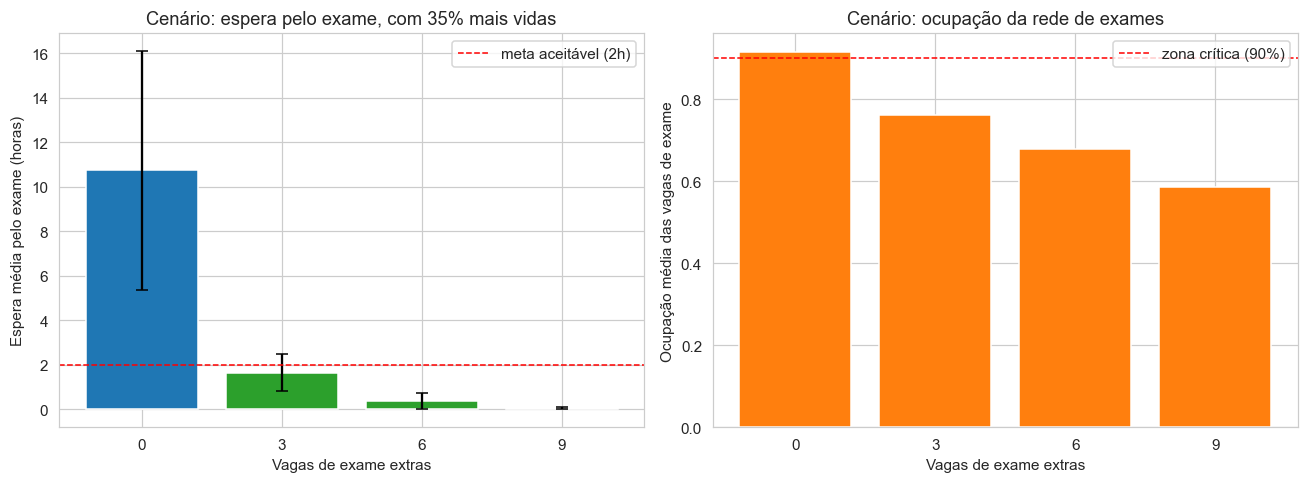

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cores = ["#1f77b4" if not r else "#2ca02c" for r in df_cenario["recomendado"]]
axes[0].bar(df_cenario["vagas_extra"].astype(str), df_cenario["espera_exame_media_h"], color=cores)
axes[0].errorbar(
    df_cenario["vagas_extra"].astype(str),
    df_cenario["espera_exame_media_h"],
    yerr=[
        df_cenario["espera_exame_media_h"] - df_cenario["ic95_baixo_h"],
        df_cenario["ic95_alto_h"] - df_cenario["espera_exame_media_h"],
    ],
    fmt="none",
    ecolor="black",
    capsize=4,
)
axes[0].axhline(META_ESPERA_EXAME_DIAS * 24, color="red", linestyle="--", linewidth=1, label="meta aceitável (2h)")
axes[0].set_xlabel("Vagas de exame extras")
axes[0].set_ylabel("Espera média pelo exame (horas)")
axes[0].set_title("Cenário: espera pelo exame, com 35% mais vidas")
axes[0].legend()

axes[1].bar(df_cenario["vagas_extra"].astype(str), df_cenario["ocupacao_exame"], color="#ff7f0e")
axes[1].axhline(0.90, color="red", linestyle="--", linewidth=1, label="zona crítica (90%)")
axes[1].set_xlabel("Vagas de exame extras")
axes[1].set_ylabel("Ocupação média das vagas de exame")
axes[1].set_title("Cenário: ocupação da rede de exames")
axes[1].legend()

plt.tight_layout()
plt.savefig("e4_fig1_cenario.png", dpi=150, bbox_inches="tight")
plt.show()

### 🔍 Como interpretar o comparativo acima

- No cenário de crescimento sem nenhum reforço (0 vagas extras), a espera pelo exame dispara e a ocupação
  passa a maior parte do tempo em zona crítica: é o sintoma que confirma a preocupação da diretoria.
- Compare as barras verdes (cenários que atingem a meta de espera) com a azul (crescimento sem ajuste,
  insuficiente).
- Repare que **mais de uma alternativa** pode satisfazer a meta: nesse caso, a escolha correta não é a
  que reduz mais a espera, e sim a **suficiente de menor custo** (Apostila E4, seção 5.3: não confundir
  "melhor resultado possível" com "recomendação defensável").
- Confira, na tabela da célula anterior, que o **tempo até a consulta muda** entre os
  cenários de vagas de exame (fica na faixa de 6,0–6,5 horas em todos eles): exames e especialistas
  disputam recursos, então esse efeito colateral também é um achado a registrar
  (Apostila E4, Tabela 6). Isso já antecipa a resposta da Pergunta 1: **reforçar só os exames não é
  suficiente** para a rede manter o nível de serviço — o gargalo dos especialistas também precisa de
  atenção (retomado na Etapa 5, Otimização).
- O custo (`custo_mensal`) só decide **entre** as alternativas que já são suficientes, nunca antes disso.


---

## Etapa 3 — Análise de Sensibilidade

### Pergunta 2: vale mais contratar mais especialistas ou agilizar a central de autorização?

**O que está sendo feito:** variar, um fator de cada vez, quatro parâmetros de entrada relevantes para o
tempo até a consulta (Apostila E4, seção 2.2 e Tabela 10): tamanho da carteira, tempo de consulta, número
de especialistas e tempo de autorização. Mede-se o efeito de cada um sobre o tempo médio até a consulta,
partindo do cenário-base (20.000 vidas, capacidade atual).

**Por que isso importa:** antes de decidir entre contratar mais especialistas e investir na central de
autorização, é preciso saber qual etapa da jornada é o maior _driver_ do tempo até a consulta (Apostila
E4, seção 7.1, Pergunta 2).

> ⚠️ **Alerta metodológico (Saltelli et al., 2017):** somente variar um fator de cada vez (OAT) é uma
> simplificação didática. Em sistemas com interações fortes entre variáveis, esse método pode
> subestimar ou mascarar efeitos. Para decisões de alto risco, métodos de sensibilidade global são mais
> robustos. Aqui, o OAT já é suficiente para separar os fatores dominantes dos secundários.

**Como interpretar:** o gráfico de tornado ordena os fatores pelo tamanho do efeito. Fatores no topo são
os que mais merecem investimento e atenção gerencial — exceto o tamanho da carteira, que é um cenário
externo (a operadora não decide quantas vidas entram), não uma variável de decisão.


In [11]:
base = ParametrosOperadora(vidas=VIDAS_BASE)
rep_base_sens = rodar_replicacoes(base, n_replicacoes=20, seed_base=SEED_BASE + 2000)
tempo_consulta_base_h = rep_base_sens["tempo_consulta_media"].mean() * 24

fatores = {
    "Crescimento de vidas (cenário, não é decisão)": (
        ParametrosOperadora(vidas=base.vidas * 0.8),
        ParametrosOperadora(vidas=base.vidas * 1.2),
    ),
    "Tempo de consulta médica": (
        ParametrosOperadora(vidas=base.vidas, fator_tempo_consulta=0.8),
        ParametrosOperadora(vidas=base.vidas, fator_tempo_consulta=1.2),
    ),
    "Número de especialistas credenciados": (
        ParametrosOperadora(vidas=base.vidas, n_especialistas=base.n_especialistas - 1),
        ParametrosOperadora(vidas=base.vidas, n_especialistas=base.n_especialistas + 1),
    ),
    "Tempo de autorização (central de autorização)": (
        ParametrosOperadora(vidas=base.vidas, fator_tempo_autorizacao=1.3),
        ParametrosOperadora(vidas=base.vidas, fator_tempo_autorizacao=0.7),
    ),
}

linhas_sens = []
for nome_fator, (params_baixo, params_alto) in fatores.items():
    rep_baixo = rodar_replicacoes(params_baixo, n_replicacoes=20, seed_base=SEED_BASE + 3000)
    rep_alto = rodar_replicacoes(params_alto, n_replicacoes=20, seed_base=SEED_BASE + 4000)
    linhas_sens.append(
        {
            "fator": nome_fator,
            "tempo_consulta_baixo_h": rep_baixo["tempo_consulta_media"].mean() * 24,
            "tempo_consulta_alto_h": rep_alto["tempo_consulta_media"].mean() * 24,
        }
    )

df_sens = pd.DataFrame(linhas_sens)
df_sens["efeito_absoluto_h"] = (df_sens["tempo_consulta_alto_h"] - df_sens["tempo_consulta_baixo_h"]).abs()
df_sens = df_sens.sort_values("efeito_absoluto_h", ascending=True).reset_index(drop=True)
df_sens["pct_da_variacao_total"] = df_sens["efeito_absoluto_h"] / df_sens["efeito_absoluto_h"].sum()

print(f"Tempo até a consulta no cenário-base: {tempo_consulta_base_h:.2f} h")
df_sens.round(2)

Tempo até a consulta no cenário-base: 2.51 h


,fator,tempo_consulta_baixo_h,tempo_consulta_alto_h,efeito_absoluto_h,pct_da_variacao_total
0,Tempo de consulta médica,2.35,3.11,0.75,0.12
1,"Crescimento de vidas (cenário, não é decisão)",2.18,3.28,1.10,0.17
2,Número de especialistas credenciados,3.46,2.35,1.11,0.17
3,Tempo de autorização (central de autorização),5.10,1.71,3.39,0.53


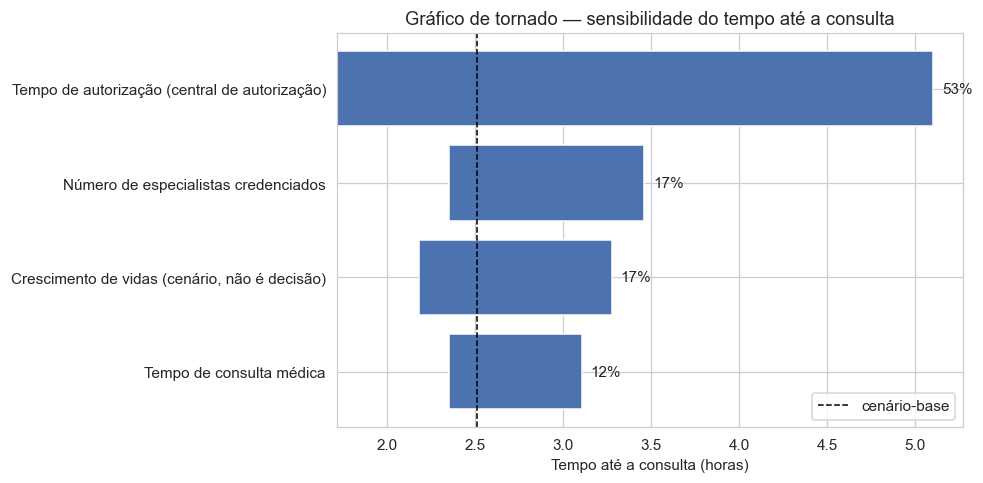

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y_pos = np.arange(len(df_sens))

esquerda = np.minimum(df_sens["tempo_consulta_baixo_h"], df_sens["tempo_consulta_alto_h"])
largura = df_sens["efeito_absoluto_h"]

barras = ax.barh(y_pos, largura, left=esquerda, color="#4c72b0")
ax.axvline(tempo_consulta_base_h, color="black", linestyle="--", linewidth=1, label="cenário-base")
ax.set_yticks(y_pos)
ax.set_yticklabels(df_sens["fator"])
ax.set_xlabel("Tempo até a consulta (horas)")
ax.set_title("Gráfico de tornado — sensibilidade do tempo até a consulta")
ax.legend()

for i, row in df_sens.iterrows():
    ax.text(esquerda.iloc[i] + largura.iloc[i] + 0.05, i, f"{row['pct_da_variacao_total']:.0%}", va="center")

plt.tight_layout()
plt.savefig("e4_fig2_sensibilidade.png", dpi=150, bbox_inches="tight")
plt.show()

### 🔍 Como interpretar o tornado

- Os fatores no **topo do gráfico** são os que mais deslocam o tempo até a consulta quando variam.
- O **tempo de autorização** domina o ranking entre os fatores controláveis: acelerar ou desacelerar a
  central de autorização em 30% desloca o tempo até a consulta muito mais do que a mesma variação
  percentual no número de especialistas ou no tempo de consulta.
- O **crescimento de vidas** também tem efeito grande, mas não é uma variável de decisão — é o cenário
  externo que motivou a Pergunta 1. Ele entra no gráfico como referência, não como candidato a
  investimento.
- A leitura gerencial é: entre contratar mais especialistas e agilizar a central de autorização (por
  exemplo, com autorização automática para procedimentos de baixa complexidade, mais auditores, ou
  digitalização do fluxo), **a central de autorização tem o maior potencial de retorno por unidade de
  esforço**.
- Esta seção não decide sozinha; ela **prioriza onde a análise de otimização (Etapa 5) deve procurar** a
  melhor combinação de recursos.


---

## Etapa 4 — Análise de Risco

### Pergunta 3: qual o risco de a rede sair do controle mesmo em regime normal, e qual o custo disso?

**O que está sendo feito:** rodar o cenário de crescimento (27.000 vidas, capacidade atual) com muitas
réplicas e descrever a **distribuição completa** do tempo até a consulta, não apenas a média.

**Por que isso importa:** a combinação entre simulação e distribuição completa dos resultados é mais
relevante para a decisão do que qualquer média isolada (Apostila E4, seção 2.4). Uma rede pode "aguentar
em média" e ainda assim deixar uma fração relevante de beneficiários muito acima da meta.

**Como interpretar:** olhe os percentis junto com a probabilidade de exceder a **meta interna** de 24
horas (1 dia útil de expediente), e compare com o risco de congestionamento da rede de exames (fração do
tempo em que a ocupação passa de 95%).


In [13]:
N_REPLICACOES_RISCO = 30
params_risco = ParametrosOperadora(vidas=VIDAS_CRESCIMENTO)  # crescimento de carteira, capacidade atual

todas_solicitacoes = []
linhas_risco = []
for rep in range(N_REPLICACOES_RISCO):
    rng = np.random.default_rng(SEED_BASE + 5000 + rep)
    df, df_ocup_esp, df_ocup_exame = simular_operadora(params_risco, rng)
    df["replicacao"] = rep
    todas_solicitacoes.append(df)
    linhas_risco.append(
        {
            "replicacao": rep,
            "pct_tempo_exame_critico": (df_ocup_exame["ocupacao"] > LIMITE_OCUPACAO_CRITICA).mean(),
        }
    )

df_solicitacoes_risco = pd.concat(todas_solicitacoes, ignore_index=True)
df_solicitacoes_risco["tempo_ate_consulta_h"] = df_solicitacoes_risco["tempo_ate_consulta"] * 24
df_risco_rep = pd.DataFrame(linhas_risco)

prob_congestionamento = df_risco_rep["pct_tempo_exame_critico"].mean()
p50 = df_solicitacoes_risco["tempo_ate_consulta_h"].quantile(0.50)
p75 = df_solicitacoes_risco["tempo_ate_consulta_h"].quantile(0.75)
p90 = df_solicitacoes_risco["tempo_ate_consulta_h"].quantile(0.90)
p95 = df_solicitacoes_risco["tempo_ate_consulta_h"].quantile(0.95)
p99 = df_solicitacoes_risco["tempo_ate_consulta_h"].quantile(0.99)
media_h = df_solicitacoes_risco["tempo_ate_consulta_h"].mean()
prob_acima_meta = (df_solicitacoes_risco["tempo_ate_consulta_h"] > META_INTERNA_HORAS).mean()

print(f"Réplicas: {N_REPLICACOES_RISCO} | Solicitações analisadas: {len(df_solicitacoes_risco)}")
print(f"Tempo até a consulta — média: {media_h:.2f} h | P50: {p50:.2f} h | P75: {p75:.2f} h")
print(f"Tempo até a consulta — P90: {p90:.2f} h | P95: {p95:.2f} h | P99: {p99:.2f} h")
print(f"P(tempo até a consulta > meta interna de {META_INTERNA_HORAS:.0f}h) = {prob_acima_meta:.2%}")
print(f"Fração média do tempo com a rede de exames em zona crítica (ocupação > 95%) = {prob_congestionamento:.1%}")

Réplicas: 30 | Solicitações analisadas: 42902
Tempo até a consulta — média: 6.09 h | P50: 4.67 h | P75: 7.67 h
Tempo até a consulta — P90: 12.09 h | P95: 15.71 h | P99: 23.54 h
P(tempo até a consulta > meta interna de 24h) = 0.91%
Fração média do tempo com a rede de exames em zona crítica (ocupação > 95%) = 61.9%


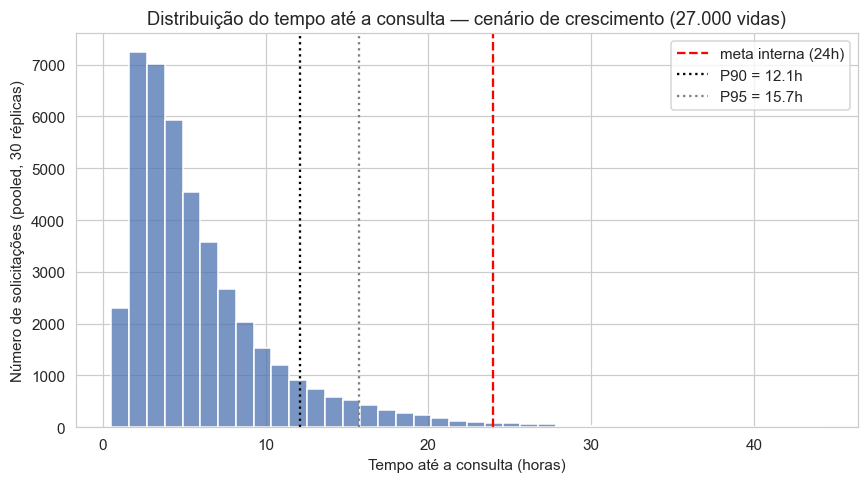

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df_solicitacoes_risco["tempo_ate_consulta_h"], bins=40, color="#4c72b0", ax=ax)
ax.axvline(META_INTERNA_HORAS, color="red", linestyle="--", linewidth=1.5, label=f"meta interna ({META_INTERNA_HORAS:.0f}h)")
ax.axvline(p90, color="black", linestyle=":", linewidth=1.5, label=f"P90 = {p90:.1f}h")
ax.axvline(p95, color="gray", linestyle=":", linewidth=1.5, label=f"P95 = {p95:.1f}h")
ax.set_xlabel("Tempo até a consulta (horas)")
ax.set_ylabel(f"Número de solicitações (pooled, {N_REPLICACOES_RISCO} réplicas)")
ax.set_title("Distribuição do tempo até a consulta — cenário de crescimento (27.000 vidas)")
ax.legend()
plt.tight_layout()
plt.savefig("e4_fig3_risco.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
CUSTO_POR_HORA_EXCEDENTE = 40.0  # R$ por hora acima da meta operacional apertada, parâmetro didático
META_OPERACIONAL_HORAS = 6.0     # meta mais apertada: resposta ainda no mesmo turno de atendimento

df_solicitacoes_risco["horas_excedentes"] = (
    df_solicitacoes_risco["tempo_ate_consulta_h"] - META_OPERACIONAL_HORAS
).clip(lower=0)

solicitacoes_por_mes = df_solicitacoes_risco.groupby("replicacao").size().mean()
custo_esperado_mensal = (
    df_solicitacoes_risco.groupby("replicacao")["horas_excedentes"].sum().mean() * CUSTO_POR_HORA_EXCEDENTE
)

print(f"Solicitações por réplica de 30 dias (média): {solicitacoes_por_mes:.0f}")
print(f"Custo esperado do tempo excedente acima de {META_OPERACIONAL_HORAS:.0f}h, por mês: R$ {custo_esperado_mensal:,.0f}")

Solicitações por réplica de 30 dias (média): 1430
Custo esperado do tempo excedente acima de 6h, por mês: R$ 98,760


### 🔍 Como interpretar os números de risco

- A probabilidade de exceder a meta interna, e não a média geral do tempo até a consulta, é o número que
  deve orientar decisões sobre reforçar ou não a rede (Apostila E4, Tabela 15).
- Mesmo com uma probabilidade de descumprimento da meta interna relativamente baixa, a **cauda da
  distribuição** (P95, P99) mostra que uma fração pequena, mas não desprezível, de beneficiários enfrenta
  esperas muito acima da média — e é essa cauda pesada, não a média, que concentra a maior parte do custo
  esperado calculado acima.
- O custo por hora excedente (parâmetro didático) é calibrável para o custo real de reputação,
  NPS, glosa ou SLA contratual da operadora.
- A fração de tempo com a rede de exames em zona crítica é um indicador complementar de **risco de
  congestionamento**: mesmo sem violar formalmente nenhum SLA, uma rede que passa a maior parte do tempo
  quase saturada tem pouca margem para absorver picos de demanda ou imprevistos (ex.: um auditor de
  licença, um especialista credenciado que sai da rede).
- Todos os prazos aqui medidos são o **tempo interno de regulação e agendamento**, sempre muito abaixo do
  teto regulatório da ANS (14 dias úteis para especialista, 21 para exame de alta complexidade — RN
  566/2022). O risco discutido nesta seção é de natureza **operacional e de experiência do beneficiário**,
  não de descumprimento regulatório.


---

## Etapa 5 — Análise de Otimização

### Combinando as Perguntas 1 e 2: quantos especialistas e quantas vagas de exame extras?

**O que está sendo feito:** buscar, dentre um conjunto pequeno de combinações de especialistas extras
(`0, 2, 4`) e vagas de exame extras (`0, 3, 6`), a que minimiza o custo mensal sujeito a duas restrições,
no cenário de crescimento (27.000 vidas):

- tempo até a consulta médio abaixo de 5 horas;
- menos de 20% do tempo com a rede de exames em zona crítica.

> 📌 **Por que testar as duas alavancas juntas:** a Etapa 2 mostrou que reforçar só os exames não move o
> tempo até a consulta (gargalo dos especialistas continua). A Etapa 3 mostrou que, isoladamente, agilizar
> a central de autorização é a alavanca de maior efeito — mas essa opção não resolve, sozinha, o
> congestionamento da rede de exames, que é um recurso físico diferente. Esta etapa combina especialistas
> e exames (as duas variáveis de capacidade física) para achar a combinação de menor custo que atende às
> duas metas ao mesmo tempo.

**Por que isso importa:** replica, em escala pequena, a lógica de otimização via simulação descrita por
Amaran et al. (2017) e o exemplo ilustrativo da Tabela 13 da apostila: a simulação avalia cada combinação
sob variabilidade real, e o algoritmo busca, dentre as combinações **viáveis**, a de menor custo.

> ⚠️ **Simplificação didática:** aqui usamos busca exaustiva (_grid search_) porque o espaço de decisões
> é pequeno (9 combinações). Para espaços maiores ou contínuos, Amaran et al. (2017) apontam a
> necessidade de algoritmos de otimização via simulação mais sofisticados.


In [16]:
CUSTO_ESPECIALISTA_EXTRA_MES = 12000.0  # R$/mês por especialista extra credenciado (parâmetro didático)

LIMITE_TEMPO_CONSULTA_OTIMIZACAO_H = 5.0
LIMITE_PCT_EXAME_CRITICO_OTIMIZACAO = 0.20

linhas_otim = []
for extra_esp in [0, 2, 4]:
    for extra_exame in [0, 3, 6]:
        params = ParametrosOperadora(
            vidas=VIDAS_CRESCIMENTO,
            n_especialistas=6 + extra_esp,
            n_vagas_exame=15 + extra_exame,
        )
        rep = rodar_replicacoes(params, n_replicacoes=10, seed_base=SEED_BASE + 6000)
        custo_total = extra_esp * CUSTO_ESPECIALISTA_EXTRA_MES + extra_exame * CUSTO_VAGA_EXAME_EXTRA_MES
        tempo_consulta_media_h = rep["tempo_consulta_media"].mean() * 24
        pct_exame_critico = rep["pct_tempo_exame_critico"].mean()
        viavel = (tempo_consulta_media_h < LIMITE_TEMPO_CONSULTA_OTIMIZACAO_H) and (
            pct_exame_critico < LIMITE_PCT_EXAME_CRITICO_OTIMIZACAO
        )
        linhas_otim.append(
            {
                "especialistas_extra": extra_esp,
                "vagas_exame_extra": extra_exame,
                "tempo_consulta_media_h": tempo_consulta_media_h,
                "pct_tempo_exame_critico": pct_exame_critico,
                "custo_mensal": custo_total,
                "viavel": viavel,
            }
        )

df_otim = pd.DataFrame(linhas_otim)
df_otim_viavel = df_otim[df_otim["viavel"]].sort_values("custo_mensal")
combo_otimo = df_otim_viavel.iloc[0] if len(df_otim_viavel) else None

df_otim_ordenado = df_otim.sort_values(["viavel", "custo_mensal"], ascending=[False, True]).reset_index(drop=True)
df_otim_ordenado.round(3)

,especialistas_extra,vagas_exame_extra,tempo_consulta_media_h,pct_tempo_exame_critico,custo_mensal,viavel
0,2,3,4.149,0.155,33000.0,True
1,2,6,4.365,0.055,42000.0,True
2,4,3,3.982,0.139,57000.0,True
3,4,6,3.842,0.064,66000.0,True
4,0,0,5.681,0.591,0.0,False
5,0,3,5.391,0.173,9000.0,False
6,0,6,5.367,0.082,18000.0,False
7,2,0,4.202,0.524,24000.0,False
8,4,0,4.425,0.524,48000.0,False


In [17]:
if combo_otimo is not None:
    print("Combinação recomendada (menor custo entre as viáveis):")
    print(f"  Especialistas extra: {int(combo_otimo['especialistas_extra'])}")
    print(f"  Vagas de exame extra: {int(combo_otimo['vagas_exame_extra'])}")
    print(f"  Tempo até a consulta médio: {combo_otimo['tempo_consulta_media_h']:.2f} h "
          f"(restrição: < {LIMITE_TEMPO_CONSULTA_OTIMIZACAO_H:.0f} h)")
    print(f"  % do tempo com rede de exames crítica: {combo_otimo['pct_tempo_exame_critico']:.1%} "
          f"(restrição: < {LIMITE_PCT_EXAME_CRITICO_OTIMIZACAO:.0%})")
    print(f"  Custo mensal: R$ {combo_otimo['custo_mensal']:,.0f}")
else:
    print("Nenhuma combinação testada satisfez as duas restrições simultaneamente.")
    print("Isso também é um resultado relevante: sinaliza que o conjunto de alternativas testado é insuficiente.")

Combinação recomendada (menor custo entre as viáveis):
  Especialistas extra: 2
  Vagas de exame extra: 3
  Tempo até a consulta médio: 4.15 h (restrição: < 5 h)
  % do tempo com rede de exames crítica: 15.5% (restrição: < 20%)
  Custo mensal: R$ 33,000


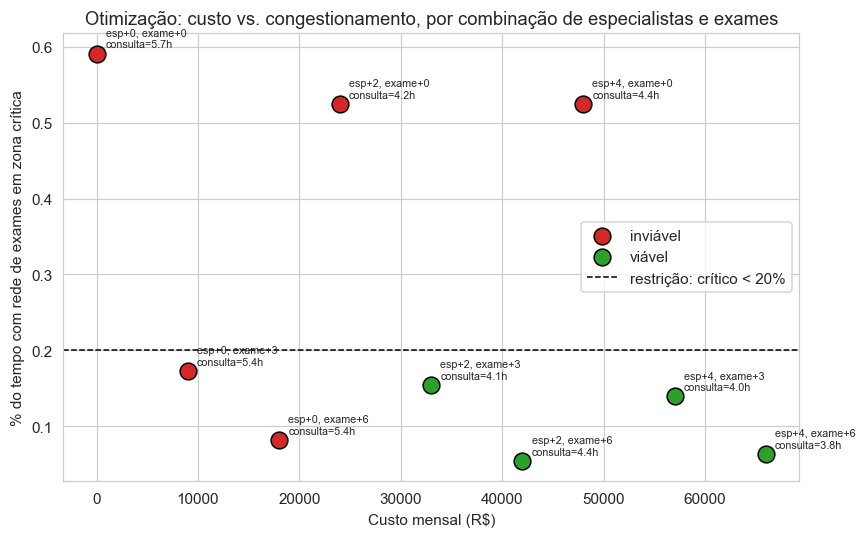

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
for viavel, grupo in df_otim.groupby("viavel"):
    ax.scatter(
        grupo["custo_mensal"],
        grupo["pct_tempo_exame_critico"],
        s=120,
        color="#2ca02c" if viavel else "#d62728",
        label="viável" if viavel else "inviável",
        edgecolor="black",
    )
    for _, linha in grupo.iterrows():
        ax.annotate(
            f"esp+{int(linha['especialistas_extra'])}, exame+{int(linha['vagas_exame_extra'])}\n"
            f"consulta={linha['tempo_consulta_media_h']:.1f}h",
            (linha["custo_mensal"], linha["pct_tempo_exame_critico"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=7,
        )

ax.axhline(LIMITE_PCT_EXAME_CRITICO_OTIMIZACAO, color="black", linestyle="--", linewidth=1, label="restrição: crítico < 20%")
ax.set_xlabel("Custo mensal (R$)")
ax.set_ylabel("% do tempo com rede de exames em zona crítica")
ax.set_title("Otimização: custo vs. congestionamento, por combinação de especialistas e exames")
ax.legend()
plt.tight_layout()
plt.savefig("e4_fig4_otimizacao.png", dpi=150, bbox_inches="tight")
plt.show()

### 🔍 Como interpretar o gráfico de otimização

- Pontos **vermelhos** violam ao menos uma restrição (tempo até a consulta ou congestionamento da rede de
  exames) e são descartados, mesmo que o custo seja baixo.
- Entre os pontos **verdes** (viáveis), a combinação recomendada é a de menor custo, seguindo a definição
  formal de otimização via simulação (Amaran et al., 2017).
- Note que reforçar só os exames (especialistas+0) nunca resolve a restrição do tempo até a consulta,
  e reforçar só os especialistas sem tocar os exames deixa o congestionamento acima da meta: as duas
  alavancas são necessárias em conjunto, confirmando o que as Etapas 2 e 3 já sinalizavam separadamente.
- Se nenhuma combinação testada for viável, a conclusão gerencial correta não é "não há solução", e sim
  "o conjunto de alternativas testado precisa ser ampliado".


---

## Etapa 6 — Do resultado da simulação ao relatório gerencial

**O que está sendo feito:** organizar as saídas das quatro análises na estrutura de cinco blocos definida
na Apostila E4, seção 4: **Problema, Métrica, Alternativas, Resultado, Recomendação**.

**Por que isso importa:** a diretoria assistencial não quer a saída bruta do simulador (Apostila E4,
seção 4). Esta célula é a ponte entre o notebook técnico e o relatório gerencial que o aluno vai
apresentar.

**Um exemplo completo e redigido**, cobrindo as três perguntas de gestão da operadora nesse mesmo formato
de cinco blocos, está no arquivo **"Relatorio_Final_Exemplo_E4.docx"**, que acompanha este notebook.


In [19]:
melhor_cenario = df_cenario[df_cenario["recomendado"]].sort_values("custo_mensal")

if len(melhor_cenario):
    linha = melhor_cenario.iloc[0]
    if linha.vagas_extra > 0:
        recomendacao = f"Contratar {int(linha.vagas_extra)} vagas de exame extras (mas ver Etapa 5: isso sozinho não resolve o tempo até a consulta)."
    else:
        recomendacao = "Não é necessário reforçar as vagas de exame: o cenário-base já atende à meta de espera."
else:
    recomendacao = (
        "Nenhum dos reforços testados (até +9 vagas) atendeu à meta de espera com ocupação segura; "
        "é preciso testar alternativas fora deste conjunto ou revisar a meta com a diretoria."
    )

resumo_pergunta_1 = {
    "Problema": "Crescimento de 35% na carteira (incorporação de cooperativa regional) sem reforço na rede credenciada.",
    "Métrica": "Tempo de espera pelo exame e ocupação da rede de exames.",
    "Alternativas": vagas_extras,
    "Resultado": {
        f"+{int(row.vagas_extra)} vagas de exame": {
            "espera_exame_h": round(row.espera_exame_media_h, 2),
            "ocupacao_pct": round(row.ocupacao_exame * 100, 1),
        }
        for row in df_cenario.itertuples()
    },
    "Recomendação": recomendacao,
}

import json

print(json.dumps(resumo_pergunta_1, indent=2, ensure_ascii=False))

{
  "Problema": "Crescimento de 35% na carteira (incorporação de cooperativa regional) sem reforço na rede credenciada.",
  "Métrica": "Tempo de espera pelo exame e ocupação da rede de exames.",
  "Alternativas": [
    0,
    3,
    6,
    9
  ],
  "Resultado": {
    "+0 vagas de exame": {
      "espera_exame_h": 10.74,
      "ocupacao_pct": 91.6
    },
    "+3 vagas de exame": {
      "espera_exame_h": 1.65,
      "ocupacao_pct": 76.2
    },
    "+6 vagas de exame": {
      "espera_exame_h": 0.36,
      "ocupacao_pct": 67.8
    },
    "+9 vagas de exame": {
      "espera_exame_h": 0.04,
      "ocupacao_pct": 58.6
    }
  },
  "Recomendação": "Contratar 3 vagas de exame extras (mas ver Etapa 5: isso sozinho não resolve o tempo até a consulta)."
}


---

## Fechamento — o que este notebook consolidou

| Etapa | Pergunta respondida                              | Tipo de análise | Entrega principal                                         |
| ----- | ------------------------------------------------ | --------------- | --------------------------------------------------------- |
| 2     | A rede aguenta 35% mais vidas?                   | Cenário + Risco | Tabela e gráfico comparando 0/3/6/9 vagas de exame extras |
| 3     | Especialista extra ou central de autorização?    | Sensibilidade   | Gráfico de tornado com o ranking de drivers               |
| 4     | Qual o risco e o custo da cauda da distribuição? | Risco           | Percentis do tempo até a consulta e custo esperado        |
| 5     | Quantos especialistas e vagas de exame extras?   | Otimização      | Combinação de menor custo entre as viáveis                |
| 6     | Como comunicar isso à diretoria?                 | —               | Ponte para o relatório de 5 blocos                        |

### 📚 Referências

- ALENANY, E.; AIT EL CADI, A. Modeling patient flow in the emergency department using machine learning and simulation. arXiv:2012.01192, 2020.
- AMARAN, S. et al. Simulation optimization: a review of algorithms and applications. arXiv:1706.08591, 2017.
- AGÊNCIA NACIONAL DE SAÚDE SUPLEMENTAR (ANS). Resolução Normativa nº 566, de 2022 — prazos máximos para garantia de atendimento.
- CHOUDHURY, A. Early prediction of post-acute care discharge disposition using predictive analytics. arXiv:1812.10487, 2018.
- FORBUS, J. J.; BERLEANT, D. Discrete-event simulation in healthcare settings: a review. arXiv:2211.00061, 2022.
- KRAMER, A. et al. Successful implementation of discrete event simulation: the case of an Italian emergency department. arXiv:2006.13062, 2020.
- MAHYOUB, M. Integrating machine learning with discrete event simulation for improving health referral processing in a care management setting. arXiv:2206.12551, 2022.
- SALTELLI, A. et al. Why so many published sensitivity analyses are false: a systematic review of sensitivity analysis practices. arXiv:1711.11359, 2017.
- SimPy Developers. SimPy Documentation. https://simpy.readthedocs.io

### 📖 Exercício para os alunos (Apostila E4, seção 9)

Adapte este notebook para uma segunda pergunta de gestão de carteira: se a operadora incorporar não 7.000,
mas 15.000 vidas adicionais, qual o novo ponto de equilíbrio de especialistas e vagas de exame? Siga o
mesmo método de cinco campos (pergunta, variável de decisão, variável de resposta, restrições, regra de
recomendação) antes de simular.
